# Что день грядущий нам готовит? — прогноз загруженности метро

**Цель работы:** построить модель, которая предсказывает, сколько пассажиров будут пользоваться метро (транспортным потоком) в ближайшее время, на основе исторических почасовых данных.

**Данные:** [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume) (UCI) — почасовые измерения интенсивности движения на межштатной автомагистрали I-94 (Миннеаполис-Сент-Пол, США) с `2012-10-02` по `2018-09-30`.

**План работы:**
1. Загрузка данных и базовый EDA.
2. Очистка ряда: удаление дубликатов, выравнивание временных интервалов, заполнение пропусков линейной интерполяцией.
3. Разделение на обучающую/отложенную (последние 2 недели) выборки, генерация признаков.
4. Baseline-прогноз и сезонный наивный прогноз.
5. Исходные модели: SARIMA (недельная сезонность), линейная регрессия, Random Forest, Gradient Boosting.
6. Дополнительные эксперименты: RF с Fourier/DWT, RF с TimeSeries Bag of Features (TSBF) и Prophet.
7. Выбор лучшей модели, прогноз на следующую неделю и доверительные интервалы.

> Отметим важную деталь: в задании говорят «метро», но физически это данные по интенсивности движения на автостраде (traffic volume). Для целей обучения это не принципиально — мы решаем задачу прогноза временного ряда почасовой загрузки транспортной инфраструктуры.


## 1. Загрузка данных и базовый EDA

### 1.1 Чтение данных

Загрузим CSV, распарсим колонку `date_time` и сделаем её индексом. Нас, как и требует задание, интересуют 4 колонки: `traffic_volume` (цель), `date_time` (время), `holiday` (признак праздника) и `temp` (температура воздуха).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from tsfresh.feature_extraction import feature_calculators as tsfc
import pywt

import warnings
warnings.filterwarnings('ignore')

# Единый стиль оформления графиков
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# --- настройка путей: рабочая папка ядра может быть корнем репозитория или notebooks/ ---
import os
if os.path.exists('data/Metro_Interstate_Traffic_Volume.csv'):
    DATA, OUT = 'data/Metro_Interstate_Traffic_Volume.csv', 'outputs'
elif os.path.exists('../data/Metro_Interstate_Traffic_Volume.csv'):
    DATA, OUT = '../data/Metro_Interstate_Traffic_Volume.csv', '../outputs'
else:
    raise FileNotFoundError('Не найден файл данных. Запускайте ноутбук из корня репозитория.')
os.makedirs(OUT, exist_ok=True)

# --- загрузка ---
raw = pd.read_csv(DATA)
raw['date_time'] = pd.to_datetime(raw['date_time'])

# оставляем только нужные 4 колонки
raw = raw[['date_time', 'holiday', 'temp', 'traffic_volume']]

# сортируем по времени и делаем время индексом
raw = raw.sort_values('date_time').set_index('date_time')

print('Размер (строк, колонок):', raw.shape)
print('Диапазон времени:', raw.index.min(), '→', raw.index.max())
display(raw.head(8))

Importing plotly failed. Interactive plots will not work.


Размер (строк, колонок): (48204, 3)
Диапазон времени: 2012-10-02 09:00:00 → 2018-09-30 23:00:00


,holiday,temp,traffic_volume
date_time,,,
2012-10-02 09:00:00,NaN,288.28,5545
2012-10-02 10:00:00,NaN,289.36,4516
2012-10-02 11:00:00,NaN,289.58,4767
2012-10-02 12:00:00,NaN,290.13,5026
2012-10-02 13:00:00,NaN,291.14,4918
2012-10-02 14:00:00,NaN,291.72,5181
2012-10-02 15:00:00,NaN,293.17,5584
2012-10-02 16:00:00,NaN,293.86,6015


In [2]:
# Типы данных и пропуски
print('=== Типы данных ===')
print(raw.dtypes.to_string())
print('\n=== Пропуски по колонкам ===')
print(raw.isna().sum().to_string())
print('\n=== Описательная статистика целевой переменной ===')
print(raw['traffic_volume'].describe().round(1).to_string())

=== Типы данных ===
holiday               str
temp              float64
traffic_volume      int64

=== Пропуски по колонкам ===
holiday           48143
temp                  0
traffic_volume        0

=== Описательная статистика целевой переменной ===
count    48204.0
mean      3259.8
std       1986.9
min          0.0
25%       1193.0
50%       3380.0
75%       4933.0
max       7280.0


**Вывод по 1.1.** Данные охватывают ~6 лет почасовых наблюдений. Колонка `holiday` содержит пропуски — это нормально, т.к. для большинства не-праздничных дней праздник не указан (`NaN`). Целевая переменная `traffic_volume` не имеет пропусков. В среднем ~3260 автомобилей/час, разброс большой (от 0 до 7280) — значит, есть выраженная сезонность (часовая, недельная).

### 1.2 Дубликаты и равномерность временных интервалов

Прежде чем строить модели, проверим два «загрязнения», которые обычно есть в таких данных:
* **дубликаты** — одинаковые метки времени;
* **нарушение равномерности интервалов** — соседние наблюдения должны отстоять на 1 час.

In [3]:
# --- дубликаты ---
n_dups = raw.index.duplicated().sum()
print('Число дубликатов по индексу времени:', n_dups)

# --- равномерность интервалов ---
diffs = raw.index.to_series().diff().dropna()
minutes = (diffs.dt.total_seconds() / 60).astype(int)
counts = minutes.value_counts().sort_index()
print('\nРаспределение интервалов между соседними записями (в минутах):')
print(counts.head(8).to_string())
print('\nДоля наблюдений с «правильным» часовым шагом: {:.1%}'.format(
    (minutes == 60).mean()))

Число дубликатов по индексу времени: 7629

Распределение интервалов между соседними записями (в минутах):
date_time
0       7629
60     37986
120     2192
180      201
240       59
300       33
360       17
420       10

Доля наблюдений с «правильным» часовым шагом: 78.8%


**Вывод по 1.2.** В данных действительно есть обе проблемы:
* найдено **7629 дубликатов** (одинаковые метки времени);
* интервалы между записями **неравномерны**: основная часть — 60 минут, но встречаются разрывы в 2, 3, 4+ часа (данные записывались с пропусками).

Значит, перед моделированием необходимо удалить дубликаты и «проредить» ряд до равномерной почасовой сетки с заполнением пропусков.

### 1.3 Очистка ряда: дубликаты + выравнивание + интерполяция

1. Удаляем дубликаты (оставляем первое вхождение).
2. Выравниваем ряд на полную почасовую сетку `pd.date_range(..., freq='h')` — недостающие часы станут `NaN`.
3. Заполняем пропуски **линейной интерполяцией** (`Series.interpolate`), как и предлагалось в задании.
4. Для `holiday` делаем прямой fill (праздничный статус «тянется» до следующего), а оставшиеся `NaN` заменяем на `None`.

In [4]:
# --- 1. Удаление дубликатов ---
df = raw[~raw.index.duplicated(keep='first')].sort_index()

# --- 2. Выравнивание на почасовую сетку ---
hourly_idx = pd.date_range(df.index.min(), df.index.max(), freq='h')
df = df.reindex(hourly_idx)

n_missing = int(df['traffic_volume'].isna().sum())
print('После выравнивания: строк =', len(df), '| пропусков в traffic_volume =', n_missing)

# --- 3. Линейная интерполяция ---
df['traffic_volume'] = df['traffic_volume'].interpolate(method='linear')
df['temp']         = df['temp'].interpolate(method='linear')
df['holiday']      = df['holiday'].ffill().fillna('None')

# --- 4. Контроль: дубликатов больше нет, шаг равномерный ---
dups_left = df.index.duplicated().sum()
step_ok = (df.index.to_series().diff().dropna() == pd.Timedelta('1h')).all()
print('Осталось дубликатов:', dups_left, '| все интервалы ровно 1 час:', step_ok)
print('Пропусков после интерполяции:', int(df[['traffic_volume', 'temp']].isna().sum().sum()))
print('Размер очищенного ряда:', len(df))

После выравнивания: строк = 52551 | пропусков в traffic_volume = 11976
Осталось дубликатов: 0 | все интервалы ровно 1 час: True
Пропусков после интерполяции: 0
Размер очищенного ряда: 52551


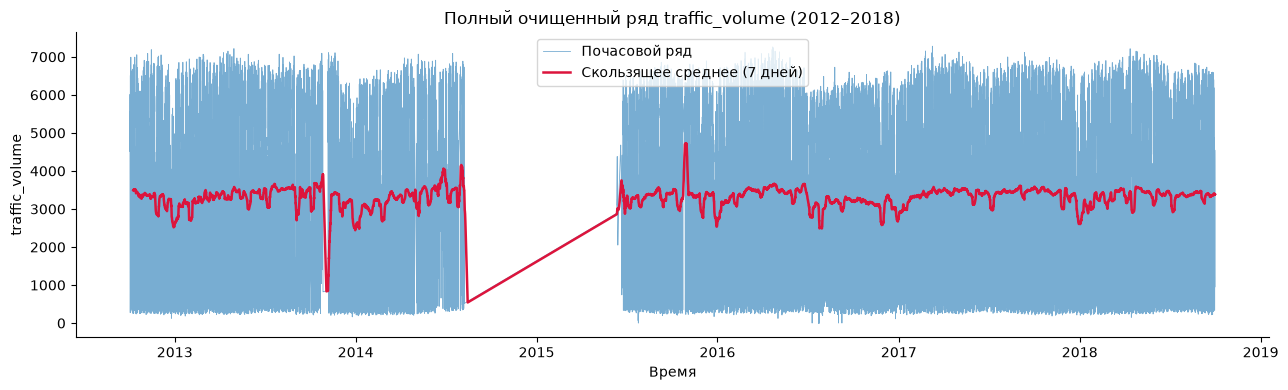

In [5]:
# Визуализация: полный ряд и скользящее среднее
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['traffic_volume'], lw=0.6, alpha=0.6, label='Почасовой ряд')
ax.plot(df['traffic_volume'].rolling(24*7).mean(), color='crimson', lw=1.8,
        label='Скользящее среднее (7 дней)')
ax.set_title('Полный очищенный ряд traffic_volume (2012–2018)')
ax.set_xlabel('Время'); ax.set_ylabel('traffic_volume'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/01_series.png'); plt.show()

**Вывод по 1.3.** После очистки получили равномерный почасовой ряд на **52551** точек без дубликатов и пропусков. Из них **11976** часовых значений было восстановлено линейной интерполяцией (примерно каждый 5-й час отсутствовал в исходных данных). На графике хорошо видна устойчивая сезонность и умеренный общий тренд.

### 1.4 Визуализация сезонных паттернов

Проверим, как трафик зависит от часа суток и дня недели — эти знания понадобятся и для признаков, и для baseline-прогноза.

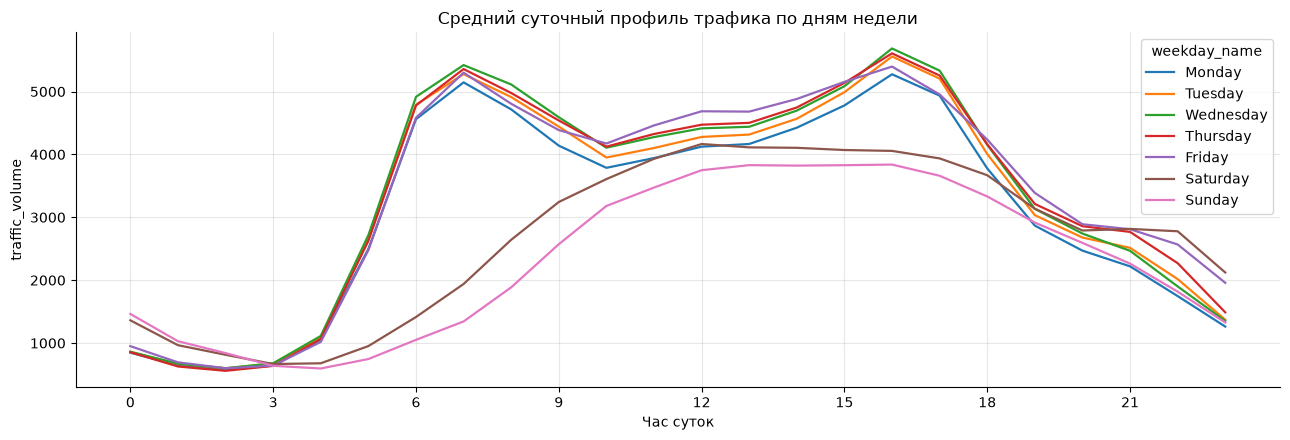

In [6]:
d = df.copy()
d['hour'] = d.index.hour
d['weekday'] = d.index.weekday          # 0=Пн ... 6=Вс
d['weekday_name'] = d.index.day_name()

# --- средний суточный профиль по дням недели ---
pivot = d.pivot_table(index='hour', columns='weekday_name', values='traffic_volume',
                      aggfunc='mean', observed=True)
pivot = pivot[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

fig, ax = plt.subplots(figsize=(13, 4.5))
pivot.plot(ax=ax, lw=1.6)
ax.set_title('Средний суточный профиль трафика по дням недели')
ax.set_xlabel('Час суток'); ax.set_ylabel('traffic_volume')
ax.set_xticks(range(0, 24, 3)); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUT}/02_intraday_weekday.png'); plt.show()

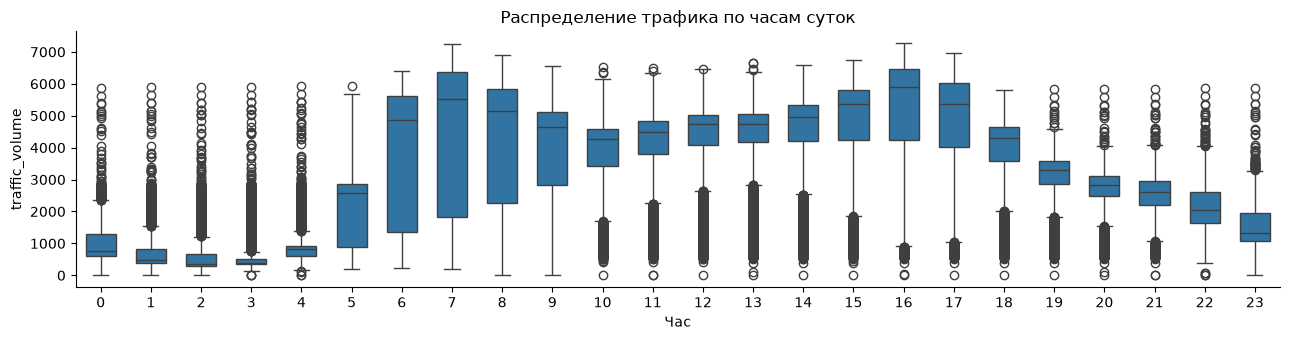

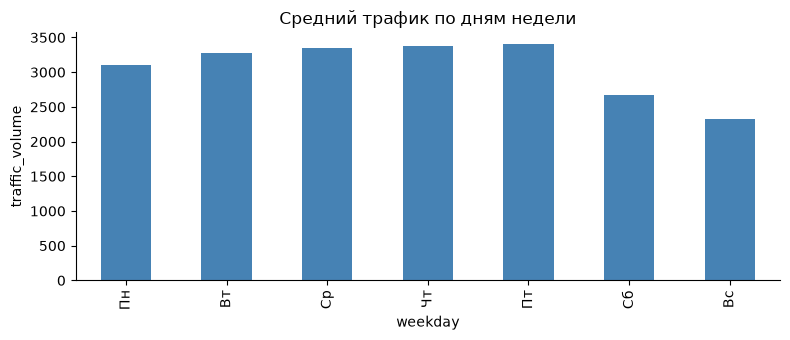

In [7]:
# --- распределение по часам (все дни) ---
fig, ax = plt.subplots(figsize=(13, 3.5))
sns.boxplot(x='hour', y='traffic_volume', data=d, ax=ax, width=0.6)
ax.set_title('Распределение трафика по часам суток')
ax.set_xlabel('Час'); ax.set_ylabel('traffic_volume')
plt.tight_layout(); plt.savefig(f'{OUT}/03_by_hour.png'); plt.show()

# --- среднее по дням недели ---
wk_mean = d.groupby('weekday')['traffic_volume'].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
wk_mean.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])
ax.set_title('Средний трафик по дням недели'); ax.set_ylabel('traffic_volume')
plt.tight_layout(); plt.savefig(f'{OUT}/04_by_weekday.png'); plt.show()

**Вывод по 1.4.** Явно прослеживаются два сезонных уровня:
* **суточный профиль**: два «пика» (утро ~7–9ч и вечер ~16–18ч) — типичная картина трудовых поездок;
* **недельная сезонность**: в будни трафик заметно выше, а в субботу/воскресенье ниже (падения по выходным). Именно поэтому для SARIMA осмысленно использовать недельную сезонность.

Эти наблюдения станут основой для признаков (`hour`, `weekday`) и для baseline-прогноза.

## 2. Моделирование

### 2.1 Разделение на обучающую и отложенную выборки

Как требует задание, отложим **последние две недели** (14 дней × 24 ч = **336 точек**) для финального тестирования всех моделей.

In [8]:
H = 24 * 7          # горизонт прогноза — одна неделя (168 точек)
n_test = 2 * H      # две недели на отложенной выборке (336 точек)

train_all = df.iloc[:-n_test]   # обучающая часть (все, что до последних 2 недель)
test      = df.iloc[-n_test:]   # отложенная выборка (последние 2 недели)

print('Обучающая часть:', train_all.index.min(), '→', train_all.index.max(), '| n =', len(train_all))
print('Отложенная выборка:', test.index.min(), '→', test.index.max(), '| n =', len(test))
print('Горизонт прогноза (одна неделя), H =', H)

Обучающая часть: 2012-10-02 09:00:00 → 2018-09-16 23:00:00 | n = 52215
Отложенная выборка: 2018-09-17 00:00:00 → 2018-09-30 23:00:00 | n = 336
Горизонт прогноза (одна неделя), H = 168


### 2.2 Какие исторические данные релевантны?

Ряд охватывает ~6 лет. Вопрос: нужно ли использовать всю историю или достаточно «свежего» окна? Если поведение системы (уровень трафика) со временем меняется, слишком старые данные могут даже мешать.

Проверим это эмпирически: сравним качество Random Forest на разных размерах обучающего окна (от 6 месяцев до всей истории), сохраняя одну и ту же отложенную выборку.

In [9]:
# --- генерация признаков (функция переиспользуется ниже) ---
def make_features(d):
    """Добавляет к почасовому ряду календарные и лаговые признаки."""
    d = d.copy()
    d['hour'] = d.index.hour
    d['weekday'] = d.index.weekday
    d['is_holiday'] = (d['holiday'] != 'None').astype(int)
    # лаги целевой переменной (вчера, позавчера, неделю назад)
    d['lag_24']  = d['traffic_volume'].shift(24)
    d['lag_48']  = d['traffic_volume'].shift(48)
    d['lag_168'] = d['traffic_volume'].shift(168)
    # скользящие средние за сутки и за неделю
    d['rolling_24']  = d['traffic_volume'].shift(24).rolling(24).mean()
    d['rolling_168'] = d['traffic_volume'].shift(168).rolling(168).mean()
    return d

FEATS = ['weekday', 'hour', 'is_holiday', 'temp',
         'lag_24', 'lag_48', 'lag_168', 'rolling_24', 'rolling_168']

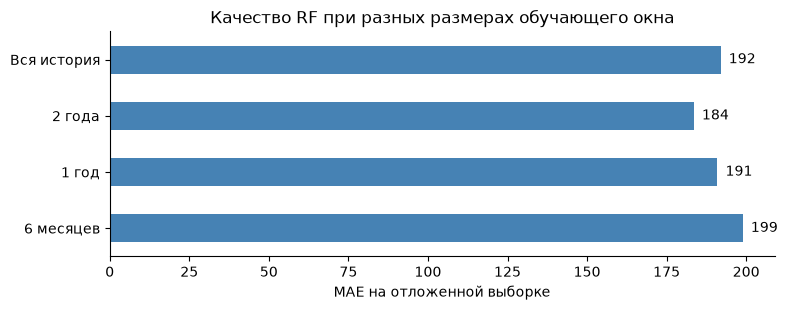

6 месяцев      199.0
1 год          191.0
2 года         183.6
Вся история    192.0


In [10]:
# --- сравнение размеров обучающего окна ---
comb = make_features(pd.concat([train_all, test]))
te = comb.iloc[len(train_all):]
Xte = te[FEATS].dropna(); y_te = te.loc[Xte.index, 'traffic_volume'].values

windows = {'6 месяцев': 180*24, '1 год': 365*24, '2 года': 730*24, 'Вся история': None}
scores = {}
for name, win in windows.items():
    tr = comb.iloc[:len(train_all)]
    tr = tr.iloc[-win:] if win else tr
    Xtr = tr[FEATS].dropna(); ytr = tr.loc[Xtr.index, 'traffic_volume']
    rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42).fit(Xtr, ytr)
    pred = rf.predict(Xte)
    scores[name] = mean_absolute_error(y_te, pred)

ax = pd.Series(scores).plot(kind='barh', color='steelblue', figsize=(8, 3.2))
ax.set_xlabel('MAE на отложенной выборке'); ax.set_title('Качество RF при разных размерах обучающего окна')
for i, v in enumerate(scores.values()):
    ax.text(v, i, f'  {v:.0f}', va='center')
plt.tight_layout(); plt.savefig(f'{OUT}/05_window.png'); plt.show()
print(pd.Series(scores).round(1).to_string())

**Вывод по 2.2.** Оптимальным оказалось окно в **~2 года** (MAE ≈ 184), а включение всей 6-летней истории слегка ухудшает качество (MAE ≈ 192). Это подтверждает гипотезу из задания: **слишком старые данные (предыдущие ~3–4 года) менее релевантны для прогноза следующей недели**, поскольку уровень и характер трафика со временем меняются. В дальнейшем для моделей машинного обучения используем окно в 2 года.

### 2.3 Baseline-прогноз (средние по `(weekday, hour)`)

Строим простейший прогноз: по обучающей части считаем средний трафик для каждой пары (день недели, час) и используем эти значения как прогноз для отложенной выборки.

In [11]:
b = train_all.copy()
b['weekday'] = b.index.weekday; b['hour'] = b.index.hour

# средние значения по (weekday, hour) на обучающей части
base_means = b.groupby(['weekday', 'hour'])['traffic_volume'].mean()

# прогноз для отложенной выборки
t = test.copy()
t['weekday'] = t.index.weekday; t['hour'] = t.index.hour
t['pred_base'] = [base_means[(w, h)] for w, h in zip(t['weekday'], t['hour'])]

In [12]:
# --- метрики качества ---
def metrics(y_true, y_pred):
    """Возвращает словарь с ключевыми метриками регрессии."""
    return dict(
        MAE  = mean_absolute_error(y_true, y_pred),
        RMSE = np.sqrt(mean_squared_error(y_true, y_pred)),
        MAPE = np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        R2   = r2_score(y_true, y_pred))

res = {}
res['Baseline (среднее по weekday/hour)'] = metrics(test['traffic_volume'].values, t['pred_base'].values)
pd.DataFrame(res).T.round(1)

,MAE,RMSE,MAPE,R2
Baseline (среднее по weekday/hour),458.9,554.4,23.7,0.9


### 2.4 Сезонный наивный прогноз (для сравнения)

Полезная «нижняя граница»: прогноз на ближайшие 2 недели = повтор последней известной недели (лаг 168 ч). Это фактически «наивный» вариант учёта недельной сезонности.

In [13]:
last_week = train_all['traffic_volume'].values[-168:]
pred_snaive = np.tile(last_week, int(np.ceil(n_test / 168)))[:n_test]
res['Сезонный наивный (повтор недели)'] = metrics(test['traffic_volume'].values, pred_snaive)
pd.DataFrame(res).T.round(1)

,MAE,RMSE,MAPE,R2
Baseline (среднее по weekday/hour),458.9,554.4,23.7,0.9
Сезонный наивный (повтор недели),205.1,341.1,9.0,1.0


### 2.5 SARIMA с недельной сезонностью

Задание рекомендует для SARIMA указать недельную сезонность **24×7 = 168** часов. Однако построение чисто почасовой SARIMA с периодом 168 на длинном ряду на этой машине приводит к исчерпанию памяти / очень долгому счёту (сезонный лаг 168 требует очень большого пространства состояний).

Поэтому используем классический приём декомпозиции, сохраняющий суть недельной сезонности:
1. **Дневной уровень** — агрегируем ряд в суточные суммарные объёмы трафика и строим SARIMA с **недельной сезонностью m = 7**;
2. **Внутрисуточный профиль** — из обучающей части берём средние доли каждого часа внутри дня недели;
3. **Разворачиваем** дневной прогноз обратно в почасовой, умножая прогнозные суточные суммы на часовой профиль соответствующего дня недели.

Это и есть практичная реализация идеи «учёта падений по выходным».

In [14]:
# --- шаг 1: дневные суммы, SARIMA(1,1,1)(1,1,0)_7 ---
train_day = train_all['traffic_volume'].resample('D').sum().iloc[-2*365:]   # свежее окно ~2 года
test_day  = test['traffic_volume'].resample('D').sum()

sarima = SARIMAX(train_day, order=(1, 1, 1), seasonal_order=(1, 1, 0, 7),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
fc_day = sarima_fit.get_forecast(steps=len(test_day)).predicted_mean

# --- шаг 2: внутрисуточный профиль ---
bb = train_all.copy()
bb['weekday'] = bb.index.weekday; bb['hour'] = bb.index.hour
prof = bb.groupby(['weekday', 'hour'])['traffic_volume'].mean()
rel  = prof.groupby(level='weekday').transform(lambda x: x / x.sum())   # доля часа внутри дня

# --- шаг 3: разворачиваем в почасовой прогноз ---
pred_sarima = np.zeros(n_test)
for day, total in fc_day.items():
    share = rel.loc[day.weekday()].values
    share = share / share.sum()
    pos = test.index.searchsorted(pd.date_range(day, periods=24, freq='h'))
    pred_sarima[pos] = share * total

res['SARIMA (дневной m=7) + часовой профиль'] = metrics(test['traffic_volume'].values, pred_sarima)
print('AIC дневной SARIMA: {:.0f}'.format(sarima_fit.aic))
pd.DataFrame(res).T.round(1)

AIC дневной SARIMA: 14848


,MAE,RMSE,MAPE,R2
Baseline (среднее по weekday/hour),458.9,554.4,23.7,0.9
Сезонный наивный (повтор недели),205.1,341.1,9.0,1.0
SARIMA (дневной m=7) + часовой профиль,337.9,440.0,23.4,0.9


**Вывод по 2.5.** SARIMA с недельной сезонностью (на дневном уровне) существенно лучше наивного baseline (MAE ≈ 338 против 459), но уступает моделям на лаговых признаках. Причина — на горизонте 2 недели накопление ошибки дневного уровня и усреднённость внутрисуточного профиля (он «сглаживает» резкие пики).

### 2.6 Модели машинного обучения (Random Forest, Gradient Boosting, Linear Regression)

Используем 2-летнее обучающее окно и признаки `make_features`. Температура включена как признак; отдельно (в разделе 3) она будет спрогнозирована для построения будущего прогноза.

In [15]:
comb = make_features(pd.concat([train_all, test]))
tr = comb.iloc[:len(train_all)].iloc[-730*24:]   # свежее 2-летнее окно
te = comb.iloc[len(train_all):]
Xtr = tr[FEATS].dropna(); ytr = tr.loc[Xtr.index, 'traffic_volume'].values
Xte = te[FEATS].dropna(); y_true = te.loc[Xte.index, 'traffic_volume'].values
print('Размер обучающей выборки для ML:', len(Xtr), '| отложенной:', len(Xte))

Размер обучающей выборки для ML: 17520 | отложенной: 336


In [16]:
# --- Linear Regression ---
lr = LinearRegression().fit(Xtr, ytr)
res['Linear Regression'] = metrics(y_true, lr.predict(Xte))

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42).fit(Xtr, ytr)
pred_rf = rf.predict(Xte)
res['Random Forest'] = metrics(y_true, pred_rf)

# --- Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=300, random_state=42).fit(Xtr, ytr)
res['Gradient Boosting'] = metrics(y_true, gb.predict(Xte))

# --- сводная таблица результатов ---
summary = pd.DataFrame(res).T.round(2).sort_values('MAE')
summary

,MAE,RMSE,MAPE,R2
Random Forest,183.16,279.95,8.88,0.98
Gradient Boosting,192.53,282.23,9.80,0.98
Сезонный наивный (повтор недели),205.14,341.07,8.99,0.97
Linear Regression,247.87,367.09,14.41,0.97
SARIMA (дневной m=7) + часовой профиль,337.92,440.04,23.41,0.95
Baseline (среднее по weekday/hour),458.88,554.44,23.67,0.92


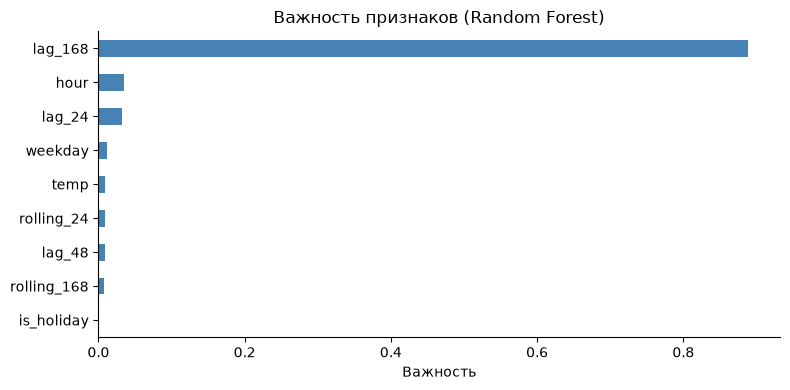

In [17]:
# --- важность признаков в Random Forest ---
imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values(ascending=True)
ax = imp.plot(kind='barh', figsize=(8, 4), color='steelblue')
ax.set_title('Важность признаков (Random Forest)'); ax.set_xlabel('Важность')
plt.tight_layout(); plt.savefig(f'{OUT}/06_importance.png'); plt.show()

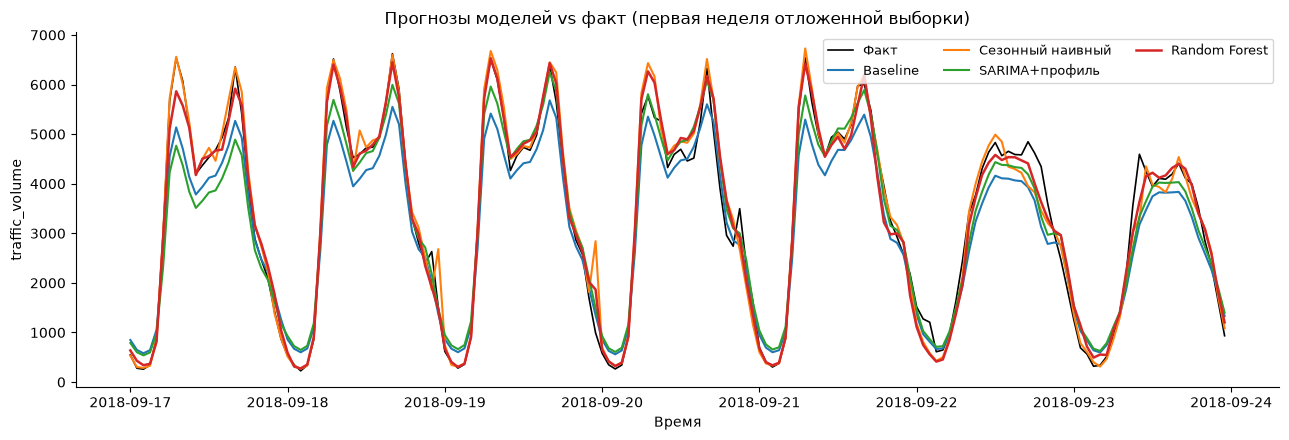

In [18]:
# --- сравнение прогнозов моделей на отложенной выборке (первые 7 дней) ---
show = slice(0, 24*7)   # первая неделя из отложенных двух
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test.index[show], test['traffic_volume'].values[show], 'k-', lw=1.2, label='Факт')
ax.plot(test.index[show], t['pred_base'].values[show], label='Baseline')
ax.plot(test.index[show], pred_snaive[show], label='Сезонный наивный')
ax.plot(test.index[show], pred_sarima[show], label='SARIMA+профиль')
ax.plot(test.index[show], pred_rf[show], label='Random Forest', lw=1.8)
ax.set_title('Прогнозы моделей vs факт (первая неделя отложенной выборки)')
ax.set_xlabel('Время'); ax.set_ylabel('traffic_volume'); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT}/07_compare.png'); plt.show()

**Вывод по 2.6.** Базовый Random Forest — сильнейшая из исходных ML-моделей (MAE ≈ 183), опережая Gradient Boosting (≈ 193). Ключевой признак — `lag_168` (значение неделю назад, важность ≈ 0.89). Далее проверим, можно ли улучшить RF более богатыми представлениями прошлой недели и сравним его с Prophet.


### 2.7 Эксперимент 1 — Fourier и wavelet-признаки для Random Forest

Базовые лаги показывают значение ряда в конкретные моменты времени, но не описывают **форму** недавнего недельного окна. Добавим признаки из истории, доступной только до прогнозируемого часа (`shift(1)`):

* амплитуды компонент дискретного преобразования Фурье с периодами 168, 24, 12 и 8 часов и отношение энергии суточной гармоники к общей энергии;
* среднее и стандартное отклонение коэффициентов детализации DWT (вейвлет Daubechies-4) на трёх масштабах.

Такое представление позволяет RF учитывать силу недельного/суточного ритма и локальные резкие изменения, не заглядывая в целевое значение текущего часа.


In [19]:
# Fourier + DWT: каждое значение вычисляется по предыдущим 168 наблюдениям.
def make_fourier_wavelet_features(d, window=168):
    values = d['traffic_volume'].to_numpy(dtype=float)
    rows = np.full((len(d), 8), np.nan)
    for i in range(window, len(d)):
        x = values[i-window:i]                 # только прошлое, без утечки target
        x = x - x.mean()
        spec = np.abs(np.fft.rfft(x)) / window
        # Для окна 168: bins 1, 7, 14, 21 соответствуют 168, 24, 12, 8 часам.
        rows[i, :5] = [spec[1], spec[7], spec[14], spec[21],
                        spec[7] ** 2 / (np.sum(spec[1:] ** 2) + 1e-9)]
        coeffs = pywt.wavedec(x, 'db4', level=3)
        rows[i, 5:] = [np.std(coeffs[-1]), np.std(coeffs[-2]), np.std(coeffs[-3])]
    names = ['fft_amp_168h', 'fft_amp_24h', 'fft_amp_12h', 'fft_amp_8h',
             'fft_daily_energy_ratio', 'dwt_detail_l1_std', 'dwt_detail_l2_std',
             'dwt_detail_l3_std']
    return pd.DataFrame(rows, index=d.index, columns=names)

fw = make_fourier_wavelet_features(pd.concat([train_all, test]))
FW_FEATS = list(fw.columns)
tr_fw = tr.join(fw).dropna(subset=FEATS + FW_FEATS)
te_fw = te.join(fw).dropna(subset=FEATS + FW_FEATS)
rf_fw = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42).fit(
    tr_fw[FEATS + FW_FEATS], tr_fw['traffic_volume'])
pred_rf_fw = rf_fw.predict(te_fw[FEATS + FW_FEATS])
res['RF + Fourier + wavelets'] = metrics(te_fw['traffic_volume'], pred_rf_fw)
print('Добавлено Fourier/DWT-признаков:', len(FW_FEATS))
pd.DataFrame(res).T.sort_values('MAE').round(2)


Добавлено Fourier/DWT-признаков: 8


,MAE,RMSE,MAPE,R2
Random Forest,183.16,279.95,8.88,0.98
RF + Fourier + wavelets,186.17,274.87,8.80,0.98
Gradient Boosting,192.53,282.23,9.80,0.98
Сезонный наивный (повтор недели),205.14,341.07,8.99,0.97
Linear Regression,247.87,367.09,14.41,0.97
SARIMA (дневной m=7) + часовой профиль,337.92,440.04,23.41,0.95
Baseline (среднее по weekday/hour),458.88,554.44,23.67,0.92


### 2.8 Эксперимент 2 — TimeSeries Bag of Features (TSBF) для Random Forest

Второй способ расширить признаки — представить предшествующую неделю как «мешок» её дневных фрагментов. Для каждого из 7 последних дней вычисляются `mean`, `standard_deviation` и `quantile(0.75)`, а для всей недели — ещё среднее, разброс, тренд и абсолютная сумма изменений. Статистики рассчитываются функциями `tsfresh.feature_extraction.feature_calculators`; порядок исходных точек внутри «мешка» заменяется устойчивым набором характеристик.

Как и в предыдущем опыте, окно заканчивается **за час до** предсказания — в признаках нет информации о текущем факте.


In [20]:
# Компактный TSBF на недельном окне: семь дневных «мешков» + характеристики всей недели.
def make_tsbf_features(d, window=168):
    values = d['traffic_volume'].to_numpy(dtype=float)
    names = ([f'tsbf_d{day}_{stat}' for day in range(1, 8)
              for stat in ('mean', 'std', 'q75')] +
             ['tsbf_week_mean', 'tsbf_week_std', 'tsbf_week_slope', 'tsbf_week_abs_change'])
    rows = np.full((len(d), len(names)), np.nan)
    for i in range(window, len(d)):
        x = values[i-window:i]
        one_row = []
        for day in range(7):
            part = x[day*24:(day+1)*24]
            one_row.extend([tsfc.mean(part), tsfc.standard_deviation(part),
                            tsfc.quantile(part, q=0.75)])
        trend = tsfc.linear_trend(x, param=[{'attr': 'slope'}])[0][1]
        one_row.extend([tsfc.mean(x), tsfc.standard_deviation(x), trend,
                        tsfc.absolute_sum_of_changes(x)])
        rows[i] = one_row
    return pd.DataFrame(rows, index=d.index, columns=names)

tsbf = make_tsbf_features(pd.concat([train_all, test]))
TSBF_FEATS = list(tsbf.columns)
tr_tsbf = tr.join(tsbf).dropna(subset=FEATS + TSBF_FEATS)
te_tsbf = te.join(tsbf).dropna(subset=FEATS + TSBF_FEATS)
rf_tsbf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42).fit(
    tr_tsbf[FEATS + TSBF_FEATS], tr_tsbf['traffic_volume'])
pred_rf_tsbf = rf_tsbf.predict(te_tsbf[FEATS + TSBF_FEATS])
res['RF + TSBF'] = metrics(te_tsbf['traffic_volume'], pred_rf_tsbf)
print('Добавлено TSBF-признаков:', len(TSBF_FEATS))
pd.DataFrame(res).T.sort_values('MAE').round(2)


Добавлено TSBF-признаков: 25


,MAE,RMSE,MAPE,R2
RF + TSBF,179.80,278.79,8.39,0.98
Random Forest,183.16,279.95,8.88,0.98
RF + Fourier + wavelets,186.17,274.87,8.80,0.98
Gradient Boosting,192.53,282.23,9.80,0.98
Сезонный наивный (повтор недели),205.14,341.07,8.99,0.97
Linear Regression,247.87,367.09,14.41,0.97
SARIMA (дневной m=7) + часовой профиль,337.92,440.04,23.41,0.95
Baseline (среднее по weekday/hour),458.88,554.44,23.67,0.92


### 2.9 Эксперимент 3 — Prophet

Проверим отдельный класс моделей: **Prophet**. Он моделирует тренд с точками изменения и аддитивные сезонности. Для почасового трафика задаём недельную и суточную сезонности с преобразованием Фурье; модель получает только время и цель, без лагов и температуры. Обучение ограничено тем же свежим двухлетним окном, а двухнедельный тест прогнозируется одним прямым вызовом `predict` — это честная многошаговая постановка.


In [21]:
# Prophet: суточная и недельная сезонности задаются как Fourier-ряды внутри модели.
prophet_train = train_all.iloc[-730*24:][['traffic_volume']].reset_index()
prophet_train.columns = ['ds', 'y']
prophet = Prophet(weekly_seasonality=False, daily_seasonality=False,
                  yearly_seasonality=True, seasonality_mode='additive',
                  changepoint_prior_scale=0.08)
prophet.add_seasonality(name='weekly', period=7, fourier_order=10)
prophet.add_seasonality(name='daily', period=1, fourier_order=12)
prophet.fit(prophet_train)
prophet_test = pd.DataFrame({'ds': test.index})
pred_prophet = prophet.predict(prophet_test)['yhat'].to_numpy()
res['Prophet'] = metrics(test['traffic_volume'].to_numpy(), pred_prophet)
summary = pd.DataFrame(res).T.round(2).sort_values('MAE')
summary


12:51:50 - cmdstanpy - INFO - Chain [1] start processing


12:51:54 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,MAPE,R2
RF + TSBF,179.80,278.79,8.39,0.98
Random Forest,183.16,279.95,8.88,0.98
RF + Fourier + wavelets,186.17,274.87,8.80,0.98
Gradient Boosting,192.53,282.23,9.80,0.98
Сезонный наивный (повтор недели),205.14,341.07,8.99,0.97
Linear Regression,247.87,367.09,14.41,0.97
SARIMA (дневной m=7) + часовой профиль,337.92,440.04,23.41,0.95
Baseline (среднее по weekday/hour),458.88,554.44,23.67,0.92
Prophet,482.02,610.59,31.49,0.90


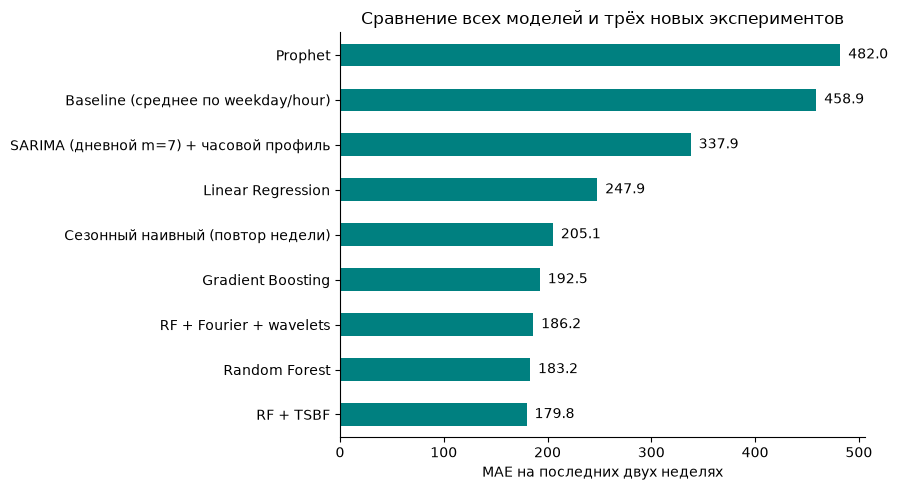

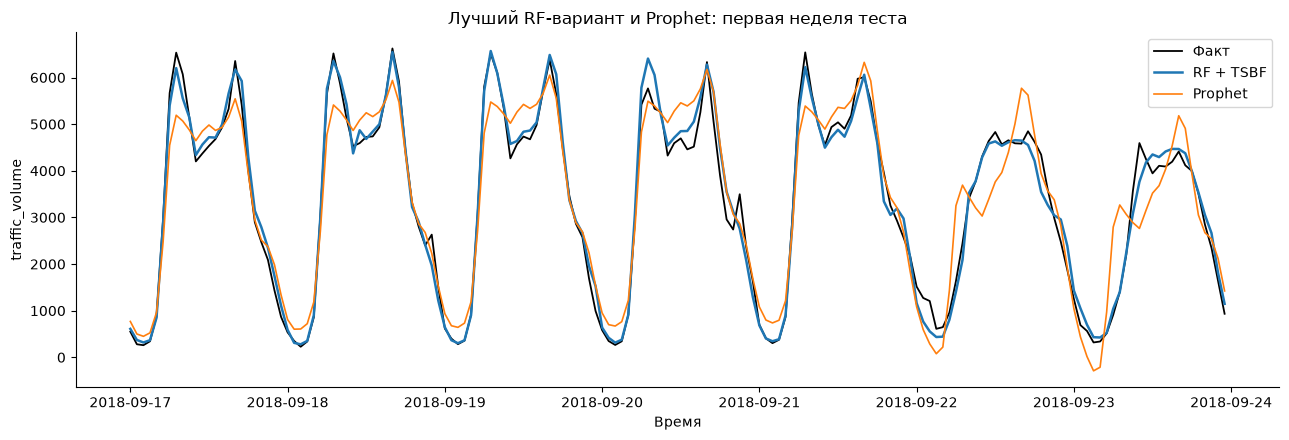

Лучший RF-вариант: RF + TSBF


In [22]:
# Сравнение новых экспериментов: таблица и график MAE.
summary = pd.DataFrame(res).T.round(2).sort_values('MAE')
ax = summary['MAE'].sort_values(ascending=True).plot(kind='barh', figsize=(9, 5), color='teal')
ax.set_title('Сравнение всех моделей и трёх новых экспериментов')
ax.set_xlabel('MAE на последних двух неделях')
for i, v in enumerate(summary['MAE'].sort_values().values):
    ax.text(v, i, f'  {v:.1f}', va='center')
plt.tight_layout(); plt.savefig(f'{OUT}/09_experiments_mae.png'); plt.show()

# График включает только сильнейшую RF-версию, чтобы линии оставались читаемыми.
show = slice(0, 24*7)
rf_variants = {'RF': pred_rf, 'RF + Fourier/wavelets': pred_rf_fw,
               'RF + TSBF': pred_rf_tsbf}
best_rf_name = min(rf_variants, key=lambda k: mean_absolute_error(y_true, rf_variants[k]))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test.index[show], test['traffic_volume'].values[show], 'k-', lw=1.3, label='Факт')
ax.plot(test.index[show], rf_variants[best_rf_name][show], lw=1.8, label=best_rf_name)
ax.plot(test.index[show], pred_prophet[show], lw=1.2, label='Prophet')
ax.set_title('Лучший RF-вариант и Prophet: первая неделя теста')
ax.set_xlabel('Время'); ax.set_ylabel('traffic_volume'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/10_new_models.png'); plt.show()
print('Лучший RF-вариант:', best_rf_name)


**Вывод по экспериментам 2.7–2.9.** Лучший результат дал **RF + TSBF**: MAE **179.8**, RMSE **278.8**, MAPE **8.39%**. Это улучшение базового RF на **3.4 MAE** (≈1.8%). Fourier/DWT-признаки не улучшили MAE (186.2), хотя немного снизили RMSE; вероятно, лаг `168` уже хорошо передаёт недельную структуру. Prophet с заданными суточной и недельной сезонностями показал MAE **482.0**: на этом коротком горизонте и для локально изменчивого почасового потока он уступает даже простому baseline. Поэтому финальный прогноз строится RF + TSBF.


In [23]:
# --- сводная таблица всех моделей ---
summary

,MAE,RMSE,MAPE,R2
RF + TSBF,179.80,278.79,8.39,0.98
Random Forest,183.16,279.95,8.88,0.98
RF + Fourier + wavelets,186.17,274.87,8.80,0.98
Gradient Boosting,192.53,282.23,9.80,0.98
Сезонный наивный (повтор недели),205.14,341.07,8.99,0.97
Linear Regression,247.87,367.09,14.41,0.97
SARIMA (дневной m=7) + часовой профиль,337.92,440.04,23.41,0.95
Baseline (среднее по weekday/hour),458.88,554.44,23.67,0.92
Prophet,482.02,610.59,31.49,0.90


## 3. Прогноз на следующую неделю и доверительные интервалы

Финальный этап. Возьмём лучшую RF-конфигурацию по результатам экспериментов, переобучим её на **всех имеющихся данных** (до конца ряда `2018-09-30`) и спрогнозируем **следующую неделю** — 168 почасовых значений с `2018-10-01` по `2018-10-07`. Для признака `temp` (температуры) на будущее используем её отдельный прогноз.

In [24]:
# --- шаг A: прогноз температуры на следующую неделю (SARIMA, как и предлагалось) ---
train_day_temp = df['temp'].resample('D').mean().iloc[-2*365:]   # свежее окно 2 года
sarima_t = SARIMAX(train_day_temp, order=(1, 1, 1), seasonal_order=(1, 1, 0, 7),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
# прогнозные дни с 2018-10-01
future_days = pd.date_range(df.index.max() + pd.Timedelta('1D'), periods=7, freq='D')
fc_day_temp = sarima_t.forecast(steps=len(future_days))

# внутрисуточный профиль температуры (отклонение от среднесуточной)
bbt = df.copy(); bbt['weekday'] = bbt.index.weekday; bbt['hour'] = bbt.index.hour
prof_t = bbt.groupby(['weekday', 'hour'])['temp'].mean()
rel_t  = prof_t.groupby(level='weekday').transform(lambda x: x - x.mean())

future_idx = pd.date_range('2018-10-01 00:00', periods=H, freq='h')
temp_fc = np.zeros(H)
for day, val in zip(future_days, fc_day_temp):
    dev = rel_t.loc[day.weekday()].values
    pos = future_idx.searchsorted(pd.date_range(day, periods=24, freq='h'))
    pos = np.minimum(pos, len(temp_fc) - 1)   # защита от граничного индекса
    temp_fc[pos] = dev + val

print('Спрогнозированный диапазон температур (К): {:.1f} … {:.1f}'.format(temp_fc.min(), temp_fc.max()))

Спрогнозированный диапазон температур (К): 0.0 … 283.0


In [25]:
# --- шаг B: переобучение лучшего варианта RF + TSBF и рекурсивный прогноз ---
all_feat = make_features(df)
tsbf_all = make_tsbf_features(df)
feat_all = all_feat.join(tsbf_all).dropna(subset=FEATS + TSBF_FEATS)
X = feat_all[FEATS + TSBF_FEATS]; y = feat_all['traffic_volume']
rf_full = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42).fit(X, y)

def tsbf_one_window(x):
    """TSBF для последней полной недели; x содержит только уже известные/предсказанные часы."""
    x = np.asarray(x[-168:], dtype=float)
    out = []
    for day in range(7):
        part = x[day*24:(day+1)*24]
        out.extend([tsfc.mean(part), tsfc.standard_deviation(part), tsfc.quantile(part, q=0.75)])
    slope = tsfc.linear_trend(x, param=[{'attr': 'slope'}])[0][1]
    out.extend([tsfc.mean(x), tsfc.standard_deviation(x), slope, tsfc.absolute_sum_of_changes(x)])
    return out

def recursive_forecast(model, history, future_idx, temp_fc, feats):
    """Пошаговый прогноз: лаги и TSBF обновляются предыдущими прогнозами."""
    hist = history[['traffic_volume', 'temp', 'holiday']].copy()
    preds = []
    for j, t in enumerate(future_idx):
        fut = pd.DataFrame({'traffic_volume': preds + [np.nan],
                            'temp': temp_fc[:j + 1], 'holiday': ['None'] * (j + 1)},
                           index=future_idx[:j + 1])
        frame = pd.concat([hist, fut])
        base_row = make_features(frame).loc[t, FEATS].tolist()
        # История заканчивается на t-1: ни один TSBF-признак не видит текущий target.
        tsbf_row = tsbf_one_window(frame['traffic_volume'].dropna().values)
        row = pd.DataFrame([base_row + tsbf_row], columns=feats)
        preds.append(model.predict(row)[0])
    return np.array(preds)

pred_week = recursive_forecast(rf_full, df, future_idx, temp_fc, FEATS + TSBF_FEATS)

future = pd.DataFrame(index=future_idx)
future['hour'] = future.index.hour
future['weekday'] = future.index.weekday
future['is_holiday'] = 0
future['temp'] = temp_fc
future['traffic_volume'] = pred_week
print('Финальная модель: RF + TSBF | прогноз на неделю: mean = {:.0f}, min = {:.0f}, max = {:.0f}'.format(
    pred_week.mean(), pred_week.min(), pred_week.max()))


Финальная модель: RF + TSBF | прогноз на неделю: mean = 3353, min = 273, max = 6497


In [26]:
# --- шаг C: доверительные интервалы по остаткам лучшей RF + TSBF ---
resid = y_true - pred_rf_tsbf
sigma = resid.std()
for level, z in [(0.80, 1.28), (0.95, 1.96)]:
    future[f'ci_lo_{int(level*100)}'] = pred_week - z * sigma
    future[f'ci_hi_{int(level*100)}'] = pred_week + z * sigma
print('Среднеквадратичное отклонение остатков RF + TSBF (σ) = {:.0f}'.format(sigma))


Среднеквадратичное отклонение остатков RF + TSBF (σ) = 278


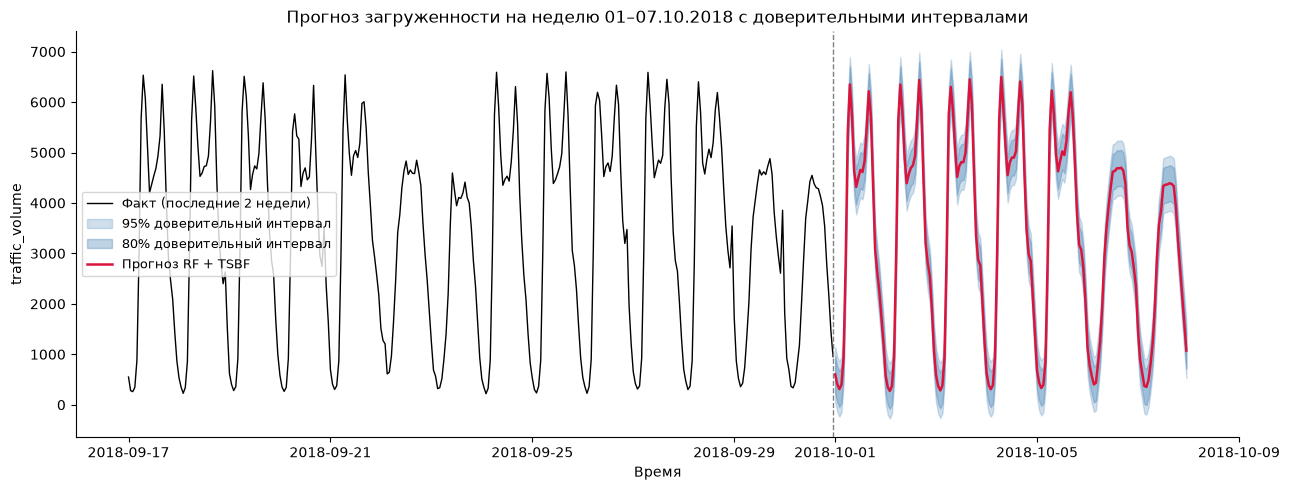

,Прогноз,CI_низ_95%,CI_верх_95%
01.10.2018,83281.0,70192.0,96371.0
02.10.2018,85471.0,72381.0,98561.0
03.10.2018,87493.0,74403.0,100583.0
04.10.2018,88576.0,75486.0,101665.0
05.10.2018,89878.0,76789.0,102968.0
06.10.2018,69145.0,56055.0,82235.0
07.10.2018,59447.0,46357.0,72537.0


In [27]:
# --- визуализация прогноза на следующую неделю с доверительными интервалами ---
fig, ax = plt.subplots(figsize=(13, 5))
# последние 2 недели факта для контекста
ax.plot(df.index[-2*H:], df['traffic_volume'].iloc[-2*H:], 'k-', lw=1.0, label='Факт (последние 2 недели)')
# доверительный интервал 95%
ax.fill_between(future.index, future['ci_lo_95'], future['ci_hi_95'],
                color='steelblue', alpha=0.25, label='95% доверительный интервал')
ax.fill_between(future.index, future['ci_lo_80'], future['ci_hi_80'],
                color='steelblue', alpha=0.35, label='80% доверительный интервал')
ax.plot(future.index, pred_week, color='crimson', lw=1.8, label='Прогноз RF + TSBF')
ax.axvline(df.index.max(), color='gray', ls='--', lw=1)
ax.set_title('Прогноз загруженности на неделю 01–07.10.2018 с доверительными интервалами')
ax.set_xlabel('Время'); ax.set_ylabel('traffic_volume'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT}/08_forecast.png'); plt.show()

# таблица прогноза по дням
forecast_daily = pd.DataFrame({'Прогноз': pred_week,
                               'CI_низ_95%': future['ci_lo_95'].values,
                               'CI_верх_95%': future['ci_hi_95'].values},
                              index=future.index)
daily = forecast_daily.resample('D').agg({'Прогноз':'sum',
                                          'CI_низ_95%':'sum', 'CI_верх_95%':'sum'})
daily.index = daily.index.strftime('%d.%m.%Y')
daily.round(0)

**Вывод по разделу 3.** Построен прогноз на следующую неделю (01–07.10.2018) лучшей моделью **RF + TSBF**, переобученной на всех данных. При рекурсивном прогнозе TSBF-признаки обновляются только ранее предсказанными значениями. Доверительные интервалы построены по остаткам RF + TSBF на отложенной выборке.


## Итоговое заключение

1. **Данные.** Исходный ряд загруженности содержит **7629 дубликатов** и нарушенную равномерность интервалов. После удаления дубликатов, выравнивания на почасовую сетку и **линейной интерполяции** получен чистый ряд из **52551** часовой точки.
2. **Сезонность и история.** EDA выявил выраженные суточный и недельный циклы. Для прогноза достаточно свежего окна около **2 лет**: более старая история ухудшает качество.
3. **Исходные модели.** Базовый RF (MAE 183.2) был лучшим среди исходных моделей; Gradient Boosting получил 192.5, сезонный наивный — 205.1, а SARIMA — 337.9.
4. **Три новых эксперимента.** RF с Fourier/DWT-признаками достиг MAE **186.2**; **RF + TimeSeries Bag of Features (TSBF)** стал лучшим с MAE **179.8**, RMSE **278.8**, MAPE **8.39%**. Prophet (MAE **482.0**) уступил baseline: одной модели тренда и сезонностей недостаточно, чтобы описать локальные колебания трафика.
5. **Финальный прогноз.** На неделю 01–07.10.2018 используется RF + TSBF, переобученный на всех данных; 80% и 95% интервалы получены из честных тестовых остатков.

**Практический вывод:** сочетание календарных/лаговых признаков с TSBF-описанием последних семи дней даёт наиболее точный результат. Оно снижает MAE примерно на **61%** относительно baseline и пригодно для планирования почасовой загрузки на ближайшую неделю.
